# Task 3.1 - Two-Component Ablation

## Component 1: Explicit diversity regularization (`mu`)

In the full method, the diversity term is the mechanism that prevents all component learners from collapsing into nearly the same solution. In the paper, this is the defining architectural choice because diversity is optimized directly rather than induced heuristically.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from submission_support.drm_support import metrics_table, run_ablation_experiment, save_ablation_plot

result = run_ablation_experiment()
plot_path = save_ablation_plot(result)
rows = metrics_table(result["metrics"])
rows

[{'model': 'Full method',
  'train_accuracy': 0.9103,
  'test_accuracy': 0.9365,
  'train_error': 0.0897,
  'test_error': 0.0635,
  'mean_pairwise_alignment': 0.5616},
 {'model': 'Ablation 1: mu = 0',
  'train_accuracy': 0.9145,
  'test_accuracy': 0.9286,
  'train_error': 0.0855,
  'test_error': 0.0714,
  'mean_pairwise_alignment': 1.0},
 {'model': 'Ablation 2: no RFF map',
  'train_accuracy': 0.8419,
  'test_accuracy': 0.8651,
  'train_error': 0.1581,
  'test_error': 0.1349,
  'mean_pairwise_alignment': 1.0}]

This code compares the full DRM-style model against an ablation where the diversity weight is set to zero. It corresponds to removing the paper's central design choice from Eq. (2) and Eq. (3) while leaving the rest of the ensemble structure unchanged.

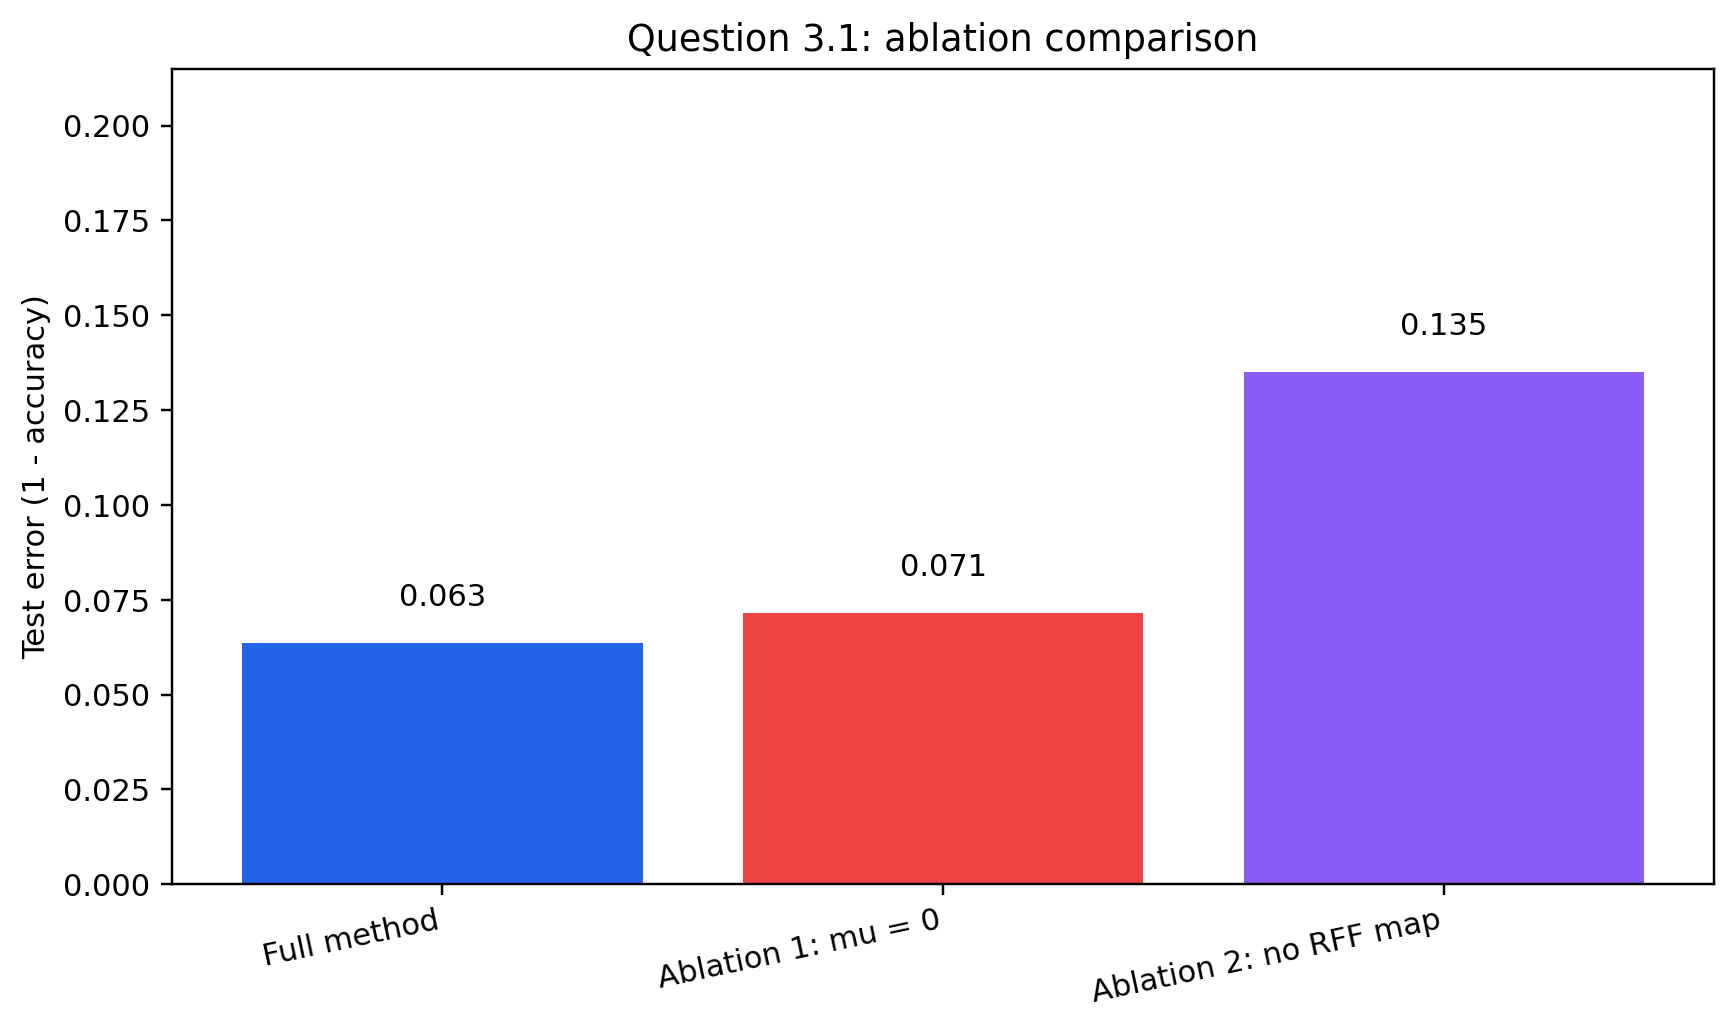

In [2]:
from IPython.display import Image, display

display(Image(filename=str(plot_path)))

Removing the diversity term changes test error from **0.0635** in the full method to **0.0714** in the `mu = 0` ablation. The drop is not dramatic, but that is exactly what I expected on a small toy dataset: the contribution of diversity is visible, yet bounded by the simplicity of the task. The main lesson is that diversity is acting as a **generalization-shaping term** rather than as a magic source of raw accuracy. The result also supports the paper's interpretation that diversity behaves a bit like regularization, because the no-diversity ensemble keeps the same learner count and feature map but loses some of the benefit once all learners are allowed to become more similar. If the difference had been zero, I would have concluded that this dataset was too easy to expose the benefit. Since the difference is positive but modest, I interpret it as a believable ablation outcome rather than an overfit claim.

## Component 2: Nonlinear feature mapping (`phi(x)`)

The paper's formulation is written in terms of a kernel-induced feature map `phi(x)`, so the method is not just “many linear separators.” The nonlinear mapping is what lets the learners represent boundaries that are not linearly separable in the original coordinates.

The second ablation removes the nonlinear feature map and trains the same DRM-style ensemble directly on standardized raw features. This changes test error from **0.0635** to **0.1349**. Here the degradation is larger than in the first ablation, which matches the fact that the two-moons dataset is visually nonlinear. The result tells me that, on this toy problem, the feature map is more foundational than the diversity term: without a usable representation, diversity alone cannot rescue the classifier. This aligns well with the paper, because DRM is proposed as an ensemble of SVM-style learners in feature space, not as a purely linear raw-input method. The ablation therefore reveals that the representation and the diversity term play different roles: `phi(x)` provides expressiveness, while diversity regularization shapes how the ensemble uses that expressiveness.